In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [3]:
df = pd.read_csv("car_data.csv")

In [4]:
print(df.head())

         Make   Model  Year Fuel_Type Transmission  Mileage     Price
0  Volkswagen  Tiguan  2022    Petrol       Manual  24532.0  20125.21
1         BMW      X3  2021    Petrol       Manual  31570.0  30899.47
2      Toyota    RAV4  2016    Petrol    Automatic  80736.0  10739.60
3  Volkswagen  Passat  2023    Petrol    Automatic   2000.0  21661.40
4         BMW    320i  2017    Diesel    Automatic  49349.0  24182.72


In [5]:
print(df.dtypes)

Make             object
Model            object
Year              int64
Fuel_Type        object
Transmission     object
Mileage         float64
Price           float64
dtype: object


In [6]:
print(df.select_dtypes('number').columns)

Index(['Year', 'Mileage', 'Price'], dtype='object')


In [7]:
print(df.select_dtypes(exclude='number').columns)

Index(['Make', 'Model', 'Fuel_Type', 'Transmission'], dtype='object')


In [8]:
print(df.describe())

              Year        Mileage         Price
count   900.000000     885.000000    885.000000
mean   2016.528889   76044.679096  13556.798768
std       4.058286   37540.440155   9050.756560
min    2010.000000    2000.000000   2641.320000
25%    2013.000000   42193.000000   6862.130000
50%    2016.000000   78277.000000  11258.740000
75%    2020.000000  106277.000000  17547.300000
max    2023.000000  161279.000000  47501.110000


In [9]:
print(df.isnull().sum())

Make             0
Model            0
Year             0
Fuel_Type        0
Transmission     0
Mileage         15
Price           15
dtype: int64


In [10]:
# (i) Cars priced above $25,000  +  their average mileage
exp = df[df['Price']>25000]
print(len(exp), exp['Mileage'].mean())

89 33858.057471264365


In [27]:
# (ii) Average price for Petrol vs Diesel
print("(ii) Avg price by fuel:")
petrol=df[df['Fuel_Type']=='Petrol']; 
diesel=df[df['Fuel_Type']=='Diesel']
print(petrol['Price'].mean())
print(diesel['Price'].mean())


(ii) Avg price by fuel:
13464.340242537315
13698.798108882522


In [26]:
# (iii) Per-make summary: average price AND maximum mileage
print(df.groupby('Make').agg(
    avg=('Price', 'mean'),
    mx=('Mileage', 'max')
))

                        avg        mx
Make                                 
Audi           21469.012615  152999.0
BMW            23870.670109  161279.0
Ford            9031.424684  157377.0
Honda          10840.866905  142862.0
Hyundai         7627.773038  142952.0
Mercedes-Benz  22786.288286  147471.0
Nissan          8841.242979  149979.0
Toyota         12109.498619  147984.0
Volkswagen     11173.912323  146747.0


In [34]:

# ---- 4a(iv)  add a Mileage Category column (Low / Moderate / High) -------------
def cat(m):
    if m < 30000:
        return "Low"
    elif m < 100000:
        return "Moderate"
    else:
        return "High"

df["Cat"] = df["Mileage"].apply(cat)
print(df[["Mileage", "Cat"]])

      Mileage       Cat
0     24532.0       Low
1     31570.0  Moderate
2     80736.0  Moderate
3      2000.0       Low
4     49349.0  Moderate
..        ...       ...
895   46172.0  Moderate
896   80009.0  Moderate
897  106007.0      High
898  132700.0      High
899   74561.0  Moderate

[900 rows x 2 columns]


In [28]:
# ---- 4a(v)  highest-priced car for every make ---------------------------------
print(
    df.loc[
        df.groupby('Make')['Price'].idxmax(),
        ['Make','Price']
    ]
)


              Make     Price
799           Audi  40768.77
207            BMW  46318.50
376           Ford  19944.79
431          Honda  24389.19
701        Hyundai  18181.10
565  Mercedes-Benz  47501.11
97          Nissan  19081.28
497         Toyota  26711.82
764     Volkswagen  24310.55


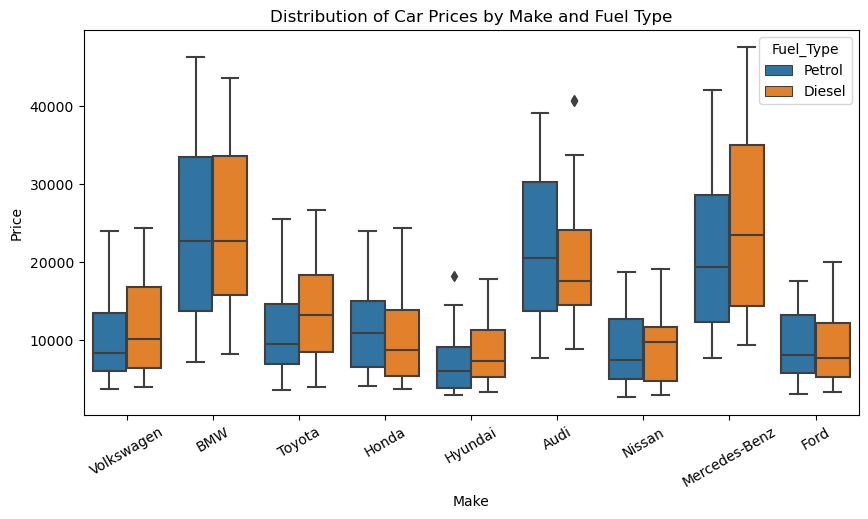

In [29]:
# ---- 4b(i)  boxplot of Price per Make, grouped by Fuel_Type --------------------
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x='Make',
    y='Price',
    hue='Fuel_Type'
)

plt.title('Distribution of Car Prices by Make and Fuel Type')
plt.xticks(rotation=30)
plt.show()

In [30]:
# ---- 4b(ii)  average price per make, ignoring rows missing Price OR Mileage ----
print(
    df.dropna(subset=['Price', 'Mileage'])
      .groupby('Make')['Price']
      .mean()
)

Make
Audi             21657.538095
BMW              23729.561209
Ford              8973.408590
Honda            10881.780560
Hyundai           7627.773038
Mercedes-Benz    22710.625000
Nissan            8841.242979
Toyota           12092.098258
Volkswagen       10973.812737
Name: Price, dtype: float64


In [31]:
# (b-iii) Distribution of Fuel_Type across Make; most popular fuel per brand.

ct = pd.crosstab(df['Make'],
                 df['Fuel_Type'])
print(ct.idxmax(axis=1))


Make
Audi             Petrol
BMW              Petrol
Ford             Diesel
Honda            Petrol
Hyundai          Petrol
Mercedes-Benz    Petrol
Nissan           Petrol
Toyota           Petrol
Volkswagen       Petrol
dtype: object


['Make', 'Model', 'Year', 'Fuel_Type', 'Transmission', 'Mileage', 'Price', 'Cat']
['Make', 'Model', 'Year', 'Fuel_Type', 'Transmission', 'Mileage', 'Price', 'Cat', 'Age']


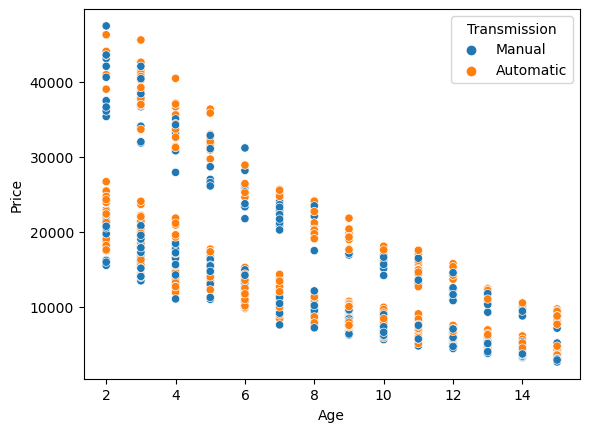

In [23]:
# ---- 4b(iv)  fuel-type distribution across brands + most common per brand -----
print(df.columns.tolist())

df["Age"] = 2025 - df["Year"]
print(df.columns.tolist())
sns.scatterplot(
    data=df,
    x='Age',
    y='Price',
    hue='Transmission'
)

plt.show()

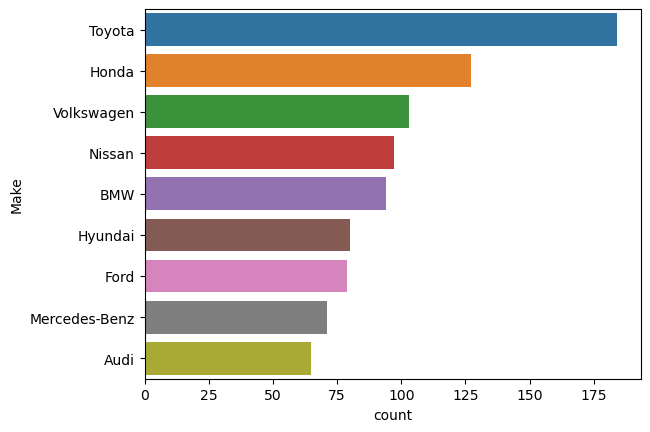

In [32]:
sns.countplot(
    data=df,
    y='Make',
    order=df['Make'].value_counts().index
)
plt.show()
